# Credit Card Fraud — EDA (train split only)

Runs on the EC2 box via SSH tunnel — the kernel, the data, and every save live on the **server**. Commit + push from the server before terminating, or the work dies with it.

**Rules**
- Only `train.csv` is loaded here. The frozen `test.csv` is never read (README → Evaluation protocol).
- Fixed class colors everywhere: **green = fraud (positive), red = legit (negative)** — colorblind-safe shades, validated.

Get the data (on the server):
```
aws s3 cp s3://cc-fraud-381491853558/data/train.csv .
```

## 1. Load & sanity

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Fixed class colors: green = fraud (positive), red = legit (negative).
# CVD-safe stand-ins for red/green (validated): bluish-green + vermillion.
C_LEGIT, C_FRAUD = "#D55E00", "#009E73"

df = pd.read_csv("train.csv", dtype="float32")  # float32: cheap habit, halves parse memory
df["Class"] = df["Class"].astype("int8")
print(df.shape)
df["Class"].value_counts()

In [2]:
assert df.isna().sum().sum() == 0, "unexpected missing values"
df.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
Time,79042.80,39505.94,0.00,145247.00
V1,-0.07,1.94,-56.41,2.45
V2,-0.01,1.66,-72.72,22.06
V3,0.18,1.49,-33.68,9.38
V4,0.04,1.41,-5.68,16.88
V5,-0.06,1.37,-42.15,34.80
V6,0.03,1.32,-26.16,22.53
V7,-0.03,1.23,-43.56,36.88
V8,0.00,1.21,-73.22,20.01
V9,0.00,1.12,-13.43,15.59


## 2. Traffic & fraud rate over time

The open question from the split: the test period's fraud rate is lower than train's — drift or burstiness? First look at the pattern *inside* train. Two stacked single-axis charts (volume above, rate below), never a dual-axis chart.

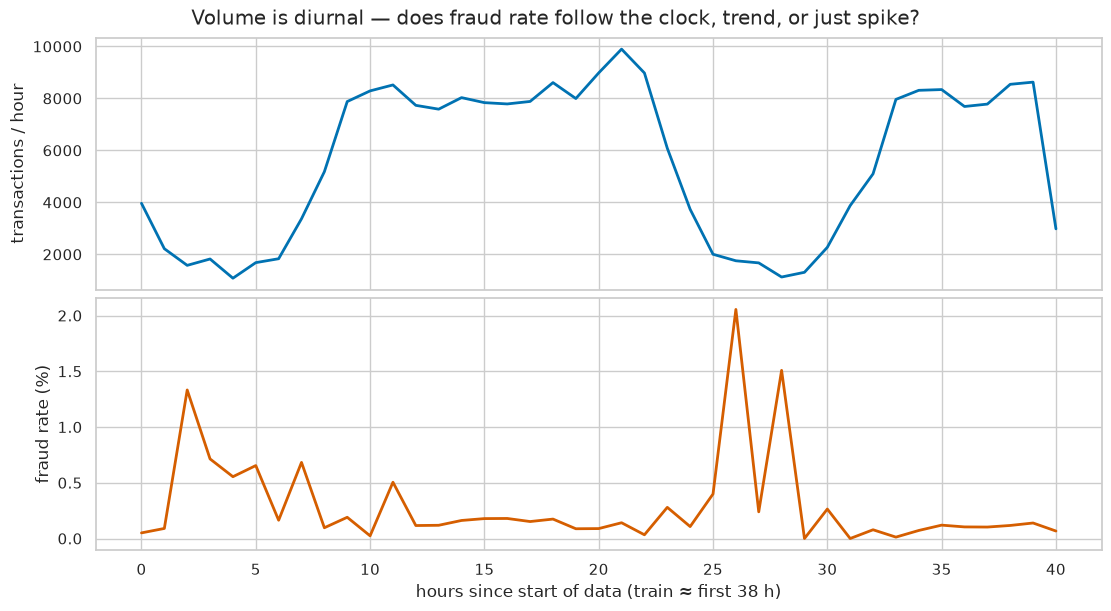

In [3]:
hour = (df["Time"] // 3600).astype(int)
per_hour = df.groupby(hour).agg(txns=("Class", "size"), fraud_rate=("Class", "mean"))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
axes[0].plot(per_hour.index, per_hour["txns"], color=C_LEGIT, lw=2)
axes[0].set_ylabel("transactions / hour")
axes[1].plot(per_hour.index, per_hour["fraud_rate"] * 100, color=C_FRAUD, lw=2)
axes[1].set_ylabel("fraud rate (%)")
axes[1].set_xlabel("hours since start of data (train ≈ first 38 h)")
fig.suptitle("Volume is diurnal — does fraud rate follow the clock, trend, or just spike?")
plt.show()

## 3. Amount

Do frauds differ in transaction size? Raw amounts are so right-skewed the plot is unreadable, so we look at `log1p(Amount)`. Densities per class (each curve's area is 1 — comparing *shapes*, not counts; counts would make the fraud curve invisible at 550:1).

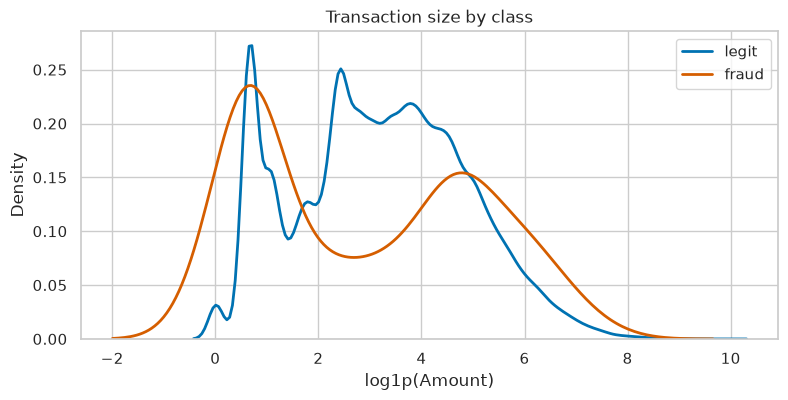

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for cls, color, label in [(0, C_LEGIT, "legit"), (1, C_FRAUD, "fraud")]:
    sns.kdeplot(np.log1p(df.loc[df["Class"] == cls, "Amount"]),
                ax=ax, color=color, lw=2, label=label)
ax.set_xlabel("log1p(Amount)")
ax.set_title("Transaction size by class")
ax.legend()
plt.show()

## 4. Which features separate fraud?

Rank every V-feature by **standardized mean difference** — how far apart the fraud and legit means sit, in units of the feature's standard deviation. Then plot the top separators' per-class densities and **read the shapes**:

- fraud curve simply *shifted* → a linear model can use this feature fine;
- fraud as a *second bump*, or extreme in *both* tails → a straight line physically can't score it, and that's evidence for nonlinear models/features (our underfitting diagnosis, made visible).

Caveat: this is univariate — a flashlight, not a map. Features that only matter in combination are invisible here.

In [6]:
v_feats = [c for c in df.columns if c.startswith("V")]
mu = df.groupby("Class")[v_feats].mean()
sep = ((mu.loc[1] - mu.loc[0]).abs() / df[v_feats].std()).sort_values(ascending=False)
sep.round(2).head(10)

V17    8.53
V14    7.32
V12    6.30
V10    5.62
V16    5.15
V3     5.13
V7     5.09
V11    3.85
V4     3.27
V18    3.05
dtype: float32

In [ ]:
top = sep.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 6), constrained_layout=True)
for f, ax in zip(top, axes.flat):
    for cls, color in [(0, C_LEGIT), (1, C_FRAUD)]:
        sns.kdeplot(df.loc[df["Class"] == cls, f], ax=ax, color=color, lw=2)
    ax.set_title(f"{f}  (separation {sep[f]:.1f}σ)")
    ax.set_xlabel("")
fig.suptitle("Top separators — red: legit, green: fraud. Read the shapes, not just the gaps.")
plt.show()

## 5. Correlations

Teaching point built into this dataset: the V's are PCA components, which are uncorrelated **by construction** — so the heatmap should be near-empty except where `Time` and `Amount` (the two raw features) meet the V's. One cell to confirm, then move on.

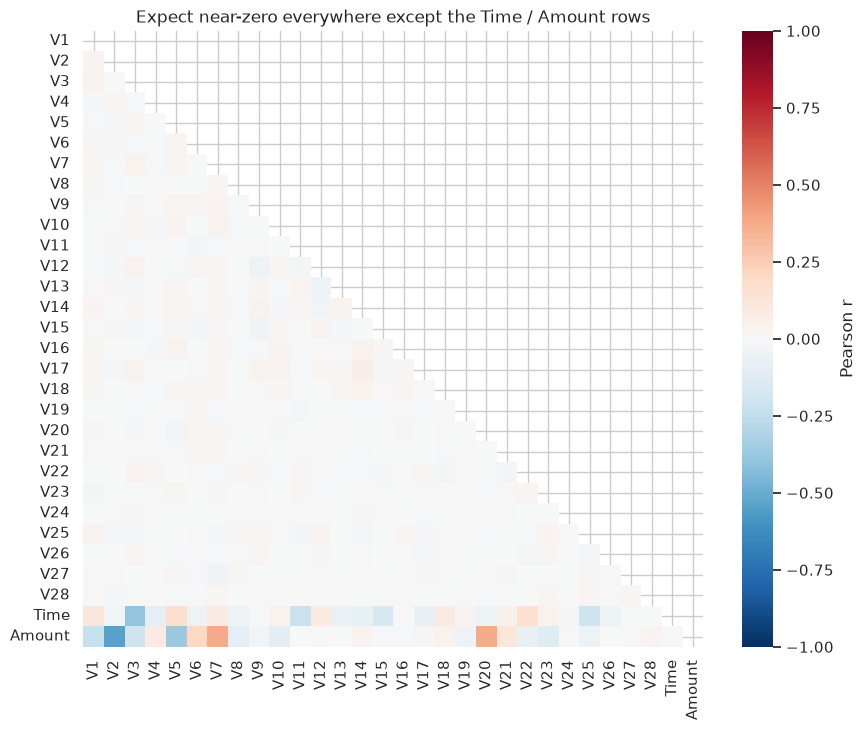

In [8]:
corr = df[v_feats + ["Time", "Amount"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Expect near-zero everywhere except the Time / Amount rows")
plt.show()

## 6. Verdict protocol

Everything above produces *hypotheses*, not conclusions. Any feature idea born here (deferred: feature engineering from section 4's winners) is judged by **validation PR-AUC** in a training run — never by eyeballing these plots, and never against the frozen test set.